# Component D — Paper Experiments (single notebook)
**Multilingual Voice-Based Stress Detection — the diagnostic paper.**

Reproduces every number/figure for the Component-D paper in ONE notebook. No `.py` files are
added to the repo; project logic is `import`ed or called from existing scripts.

### Fast design (why this is quick)
The frozen 300M encoder produces the SAME embedding regardless of checkpoint — only the tiny
fusion **head** differs. So we run the encoder **once** to cache embeddings, then evaluate every
checkpoint by running just its head (CPU, seconds). IEMOCAP uses your existing
`features_iemocap.npz`, so **§4 needs no encoder at all**.

### Honest statistical strategy
The 24-clip real set + ~6 checkpoints are **too small for classical significance** (n=5 floors
Wilcoxon at p=0.0625; inversion ρ≈−0.6 is directional). Statistical inference comes from
**IEMOCAP (§4, thousands of utterances)**; the real-clip set gives **effect sizes + bootstrap CIs
+ the honest small-sample caveat.** We never present an underpowered p-value as significant.

### Run order (Colab; GPU only speeds the one-time §2 extraction)
§0 setup → §2 extract 24-clip features once → §3 real-voice stats → §4 IEMOCAP replication.
§5 baseline + §6 figures are added into THIS notebook next pass.

## §0 · Setup — clone repo code, install, mount Drive

In [1]:
# The repo CODE (src/, scripts/) is identical on main; the paper branch only adds
# THIS notebook, which you've uploaded to Colab directly. So clone main for the code.
import os, sys
REPO="/content/R26-DS-006"
if not os.path.exists(REPO):
    !git clone --depth 1 https://github.com/SenathPerera/R26-DS-006.git {REPO}
%cd {REPO}/component-d
!git log --oneline -1

Cloning into '/content/R26-DS-006'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (303/303), done.
remote: Compressing objects: 100% (258/258), done.
remote: Total 303 (delta 38), reused 262 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (303/303), 6.82 MiB | 24.50 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/R26-DS-006/component-d
2c71b55 (grafted, HEAD -> main, origin/main, origin/HEAD) Merge pull request #15 from SenathPerera/feature/unity-project-setup


In [2]:
# Light install for analysis; funasr/torch only needed for the one-time §2 extraction.
!pip -q install -r requirements.txt
!pip -q install scipy statsmodels
import torch
print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (fine)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 30.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.4/979.4 kB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 132.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.0/156.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
# Mount Drive. Point DRIVE_ROOT at the folder that holds your assets.
from google.colab import drive; drive.mount('/content/drive')
import sys, pathlib, shutil
sys.path.insert(0, str(pathlib.Path.cwd()/'src'))   # make the componentd package importable

DRIVE_ROOT = pathlib.Path('/content/drive/MyDrive/cognivoice')   # <-- your existing folder
assert DRIVE_ROOT.exists(), f"not found: {DRIVE_ROOT} (edit DRIVE_ROOT to your Drive folder)"

# Stage checkpoints (flat *.pt in DRIVE_ROOT) into the repo's models dir.
from componentd.config import MODELS_DIR, DATA_DIR
MODELS_DIR.mkdir(parents=True, exist_ok=True)
for pt in DRIVE_ROOT.glob('*.pt'):
    shutil.copy(pt, MODELS_DIR/pt.name)
print("checkpoints staged:", sorted(p.stem for p in MODELS_DIR.glob('*.pt')))

# Stage the 24 real eval clips (upload real_voice_eval/ into DRIVE_ROOT first).
EVAL_DST = DATA_DIR/'real_voice_eval'
if (DRIVE_ROOT/'real_voice_eval').exists():
    shutil.copytree(DRIVE_ROOT/'real_voice_eval', EVAL_DST, dirs_exist_ok=True)
print("calm clips:", len(list((EVAL_DST/'calm_voice').glob('*.wav'))),
      "| stress clips:", len(list((EVAL_DST/'stress_voice').glob('*.wav'))))

CACHE = DRIVE_ROOT/'paper_cache'; CACHE.mkdir(exist_ok=True)
print("cache ->", CACHE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
checkpoints staged: ['fusion_acted', 'fusion_augmented', 'fusion_combined', 'fusion_iemocap', 'fusion_meld_baseline', 'fusion_meld_sinhala', 'fusion_v2']
calm clips: 7 | stress clips: 17
cache -> /content/drive/MyDrive/cognivoice/paper_cache


> **Before running §0**, make sure `MyDrive/cognivoice/` contains, in addition to what's already there:
> - `fusion_meld_baseline.pt`, `fusion_acted.pt`, `fusion_augmented.pt`  *(upload from your laptop:
>   `component-d/artifacts/models/`)* — the shipped model + the inversion poles
> - a `real_voice_eval/` folder with `calm_voice/` and `stress_voice/` (24 wavs)  *(from
>   `component-d/data/real_voice_eval/`)*

## §1 · From-features prediction (head only — the exact shipped math)

`predict_from_features` rebuilds a checkpoint's `GatedFusionModel`, standardises prosody with the
checkpoint's **training-time** stats, and returns predicted valence/arousal — identical to
`StressScorer.score_array`, minus the encoder (which we cache separately).

In [6]:
import numpy as np, torch, pathlib
sys.path.insert(0,'src')
from componentd.layer2_fusion import GatedFusionModel
from componentd.config import (stress_from_va, stress_from_va_legacy,
                               confidence_from_va, STRESSED_THRESHOLD, MODELS_DIR)

def load_head(ckpt_path):
    ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    cfg = ck["fusion_config"]
    m = GatedFusionModel(emb_dim=ck["emb_dim"], pros_dim=ck["pros_dim"],
                         proj_dim=cfg["proj_dim"], hidden_dim=cfg["hidden_dim"],
                         dropout=cfg["dropout"])
    m.load_state_dict(ck["state_dict"]); m.eval()
    return m, np.asarray(ck["pros_mean"],np.float32), np.asarray(ck["pros_std"],np.float32)

def predict_from_features(ckpt_path, emb, pros_raw):
    m, pmean, pstd = load_head(ckpt_path)
    pros = (pros_raw - pmean)/(pstd + 1e-8)
    with torch.no_grad():
        v,a,g = m(torch.from_numpy(emb.astype('float32')),
                  torch.from_numpy(pros.astype('float32')))
    return v.numpy(), a.numpy(), g.mean(-1).numpy()

def vprimary(v,a): return np.array([10*stress_from_va(float(x),float(y)) for x,y in zip(v,a)])
def vlegacy(v,a):  return np.array([10*stress_from_va_legacy(float(x),float(y)) for x,y in zip(v,a)])
print("helpers ready")

helpers ready


## §2 · Extract the 24 real-clip features ONCE (the only encoder step)

Runs the frozen encoder + prosody on the 24 acid-test clips a single time and caches
`realvoice_features.npz` to Drive. Every checkpoint is then evaluated from this cache with no
further encoder calls. Skips automatically if the cache exists.

In [8]:
RV_NPZ = CACHE/'realvoice_features.npz'
def language_of(name): return "sinhala" if "sinhala" in name.lower() else "english"

if RV_NPZ.exists():
    print("using cached", RV_NPZ.name)
else:
    from funasr import AutoModel
    from componentd.preprocessing import prepare
    from componentd.layer2_prosody import extract_prosody
    from componentd.config import ENCODER_ABLATIONS, SAMPLE_RATE
    import librosa
    enc = AutoModel(model=ENCODER_ABLATIONS["plus_large"], hub="ms", disable_update=True)
    embs, pros, files, labels, langs = [], [], [], [], []
    for lab, sub in [("calm","calm_voice"),("stressed","stress_voice")]:
        for w in sorted((EVAL_DST/sub).glob('*.wav')):
            raw,_ = librosa.load(str(w), sr=SAMPLE_RATE, mono=True)
            audio, ok, _ = prepare(raw, SAMPLE_RATE)
            if not ok:
                print("rejected by quality gate:", w.name); continue
            r = enc.generate(audio, granularity="utterance", extract_embedding=True, disable_pbar=True)
            embs.append(np.asarray(r[0]["feats"],np.float32)); pros.append(extract_prosody(audio))
            files.append(w.name); labels.append(lab); langs.append(language_of(w.name))
    np.savez_compressed(RV_NPZ, emb=np.stack(embs), pros=np.stack(pros),
                        fname=np.array(files), label=np.array(labels), language=np.array(langs))
    print("cached", len(files), "clips ->", RV_NPZ)

funasr version: 1.4.3.


2026-08-23 03:45:00,072 | INFO    | modelscope_hub.download | Downloading 12 files from iic/emotion2vec_plus_large@master


Downloading:   0%|          | 0/12 [00:00<?, ?file/s]

Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.bias, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: m

In [9]:
import pandas as pd
rv = np.load(RV_NPZ, allow_pickle=True)
RV_EMB, RV_PROS = rv["emb"], rv["pros"]
rv_meta = pd.DataFrame(dict(file=rv["fname"], label=rv["label"], language=rv["language"]))
print(len(rv_meta), "clips |", rv_meta.label.value_counts().to_dict(), "|", rv_meta.language.value_counts().to_dict())

# Score every checkpoint from the cached features (instant).
MAIN = ["fusion_acted","fusion_v2","fusion_combined","fusion_iemocap","fusion_meld_baseline","fusion_augmented"]
present = [c for c in MAIN if (MODELS_DIR/f"{c}.pt").exists()]
frames=[]
for ck in present:
    v,a,g = predict_from_features(MODELS_DIR/f"{ck}.pt", RV_EMB, RV_PROS)
    d = rv_meta.copy(); d["checkpoint"]=ck; d["valence"]=v; d["arousal"]=a; d["gate"]=g
    d["stress_score"]=vprimary(v,a); frames.append(d)
real_scores = pd.concat(frames, ignore_index=True)
print("scored checkpoints:", present)

24 clips | {'stressed': 17, 'calm': 7} | {'english': 13, 'sinhala': 11}
scored checkpoints: ['fusion_acted', 'fusion_v2', 'fusion_combined', 'fusion_iemocap', 'fusion_meld_baseline', 'fusion_augmented']


## §3 · Statistical rigor (Item #1)

### §3.1 The inversion — in-domain acted CCC vs real-voice accuracy

In [10]:
from scipy import stats
ACTED_CCC = {"fusion_acted":0.81,"fusion_v2":0.79,"fusion_combined":0.77,
             "fusion_iemocap":0.65,"fusion_meld_baseline":0.35}   # docs/ABLATION_STUDY.md Phase-0
def acc_at(df, thr=STRESSED_THRESHOLD):
    return ((df.stress_score.values>=thr)==(df.label.values=="stressed")).mean()
rows=[dict(checkpoint=ck, acted_ccc=ACTED_CCC[ck], real_acc=acc_at(g), n=len(g))
      for ck,g in real_scores.groupby("checkpoint") if ck in ACTED_CCC]
inv=pd.DataFrame(rows).sort_values("acted_ccc",ascending=False)
rho,p=stats.spearmanr(inv.acted_ccc,inv.real_acc)
print(inv.to_string(index=False))
print(f"\nSpearman rho={rho:+.3f} p={p:.4f} (n={len(inv)}) — report the MONOTONE inversion + effect, not p alone.")

          checkpoint  acted_ccc  real_acc  n
        fusion_acted       0.81  0.750000 24
           fusion_v2       0.79  0.875000 24
     fusion_combined       0.77  0.708333 24
      fusion_iemocap       0.65  0.791667 24
fusion_meld_baseline       0.35  0.958333 24

Spearman rho=-0.500 p=0.3910 (n=5) — report the MONOTONE inversion + effect, not p alone.


### §3.2 Bootstrap 95% CI on real-voice accuracy (active model)

In [11]:
def boot_ci(df,thr=STRESSED_THRESHOLD,B=10000,seed=0):
    rng=np.random.default_rng(seed)
    ok=((df.stress_score.values>=thr)==(df.label.values=="stressed")).astype(int)
    bs=[rng.choice(ok,len(ok),replace=True).mean() for _ in range(B)]
    return ok.mean(), np.percentile(bs,2.5), np.percentile(bs,97.5), len(ok)
act=real_scores[real_scores.checkpoint=="fusion_meld_baseline"]
for lang in ["ALL","english","sinhala"]:
    sub=act if lang=="ALL" else act[act.language==lang]
    acc,lo,hi,n=boot_ci(sub); print(f"{lang:<8} acc={acc:.3f} 95% CI [{lo:.3f},{hi:.3f}] (n={n})")

ALL      acc=0.958 95% CI [0.875,1.000] (n=24)
english  acc=1.000 95% CI [1.000,1.000] (n=13)
sinhala  acc=0.909 95% CI [0.727,1.000] (n=11)


### §3.3 d′ gain — valence-primary vs legacy (paired across checkpoints)

In [12]:
def dprime(s,c):
    s,c=np.asarray(s),np.asarray(c)
    ps=np.sqrt(((len(s)-1)*s.var(ddof=1)+(len(c)-1)*c.var(ddof=1))/(len(s)+len(c)-2))
    return (s.mean()-c.mean())/ps
rows=[]
for ck,g in real_scores.groupby("checkpoint"):
    st=(g.label=="stressed").values
    leg=vlegacy(g.valence.values,g.arousal.values); vp=vprimary(g.valence.values,g.arousal.values)
    rows.append(dict(checkpoint=ck,d_legacy=dprime(leg[st],leg[~st]),d_valprimary=dprime(vp[st],vp[~st])))
dpf=pd.DataFrame(rows); diff=(dpf.d_valprimary-dpf.d_legacy).values
W,pw=stats.wilcoxon(dpf.d_valprimary,dpf.d_legacy); cohend=diff.mean()/diff.std(ddof=1)
print(dpf.to_string(index=False))
print(f"\nmean gain={diff.mean():+.2f} Cohen's d={cohend:.2f} Wilcoxon p={pw:.4f} (n={len(dpf)}; floor={1/2**len(dpf):.4f})")

          checkpoint  d_legacy  d_valprimary
        fusion_acted  1.065054      1.519684
    fusion_augmented  2.004253      2.277661
     fusion_combined  1.018263      1.370019
      fusion_iemocap  1.107024      1.735344
fusion_meld_baseline  1.941330      2.978853
           fusion_v2  2.004253      2.277661

mean gain=+0.50 Cohen's d=1.71 Wilcoxon p=0.0312 (n=6; floor=0.0156)


### §3.4 Valence transfers / arousal collapses (the mechanism)

In [13]:
rows=[]
for ck,g in real_scores.groupby("checkpoint"):
    s=g[g.label=="stressed"]
    rows.append(dict(checkpoint=ck, valence_neg_pct=100*(s.valence<0).mean(),
                     arousal_pos_pct=100*(s.arousal>0).mean(), n=len(s)))
print(pd.DataFrame(rows).to_string(index=False))
print("\nExpected: valence_neg ~100%, arousal_pos low -> the dissociation, per model.")

          checkpoint  valence_neg_pct  arousal_pos_pct  n
        fusion_acted        82.352941        11.764706 17
    fusion_augmented        94.117647        29.411765 17
     fusion_combined       100.000000        29.411765 17
      fusion_iemocap       100.000000        52.941176 17
fusion_meld_baseline       100.000000        17.647059 17
           fusion_v2        94.117647        29.411765 17

Expected: valence_neg ~100%, arousal_pos low -> the dissociation, per model.


## §4 · IEMOCAP independent replication (Item #2 — the make-or-break)

Uses your existing `features_iemocap.npz` (real EmoVal/EmoAct labels, speaker-independent split).
No encoder. On this INDEPENDENT, large-n corpus we test whether the **dissociation replicates**:
predicted valence should track real valence far better than predicted arousal tracks real arousal.

In [14]:
IEMO = DRIVE_ROOT/'features_iemocap.npz'
assert IEMO.exists(), f"missing {IEMO}"
z=np.load(IEMO, allow_pickle=True)
print("keys:", list(z.keys()), "| n=", len(z["emb"]), "| splits:", pd.Series(z["split"]).value_counts().to_dict())
test = z["split"]=="test"
EMB_T, PROS_T = z["emb"][test], z["pros"][test]
VAL_T, ARO_T = z["valence"][test], z["arousal"][test]     # REAL human ratings
print("held-out test utterances:", test.sum(), "| speakers:", pd.Series(z["speaker"][test]).nunique())

keys: ['emb', 'pros', 'valence', 'arousal', 'stress01', 'stress_label', 'split', 'language', 'dataset', 'speaker', 'encoder'] | n= 9830 | splits: {'train': 7698, 'test': 2132}
held-out test utterances: 2132 | speakers: 2


In [15]:
from scipy.stats import pearsonr
def ccc(x,y):
    x,y=np.asarray(x,float),np.asarray(y,float)
    return 2*np.cov(x,y)[0,1]/(x.var()+y.var()+(x.mean()-y.mean())**2)
print(f"{'checkpoint':<22}{'val_r':>8}{'val_ccc':>9}{'aro_r':>8}{'aro_ccc':>9}   n")
for ck in [c for c in ["fusion_meld_baseline","fusion_acted","fusion_iemocap","fusion_v2","fusion_combined"] if (MODELS_DIR/f'{c}.pt').exists()]:
    pv,pa,_=predict_from_features(MODELS_DIR/f"{ck}.pt", EMB_T, PROS_T)
    rv,_=pearsonr(pv,VAL_T); ra,_=pearsonr(pa,ARO_T)
    print(f"{ck:<22}{rv:>8.3f}{ccc(pv,VAL_T):>9.3f}{ra:>8.3f}{ccc(pa,ARO_T):>9.3f}   {test.sum()}")
print("\nReplication holds if valence >> arousal on this independent, large-n corpus.")

checkpoint               val_r  val_ccc   aro_r  aro_ccc   n
fusion_meld_baseline     0.688    0.616   0.485    0.407   2132
fusion_acted             0.662    0.639   0.326    0.289   2132
fusion_iemocap           0.742    0.733   0.659    0.653   2132
fusion_v2                0.674    0.667   0.404    0.374   2132
fusion_combined          0.726    0.695   0.621    0.581   2132

Replication holds if valence >> arousal on this independent, large-n corpus.


In [16]:
# §3.1b — inversion under CONVENTIONAL (legacy) scoring, threshold 5.0
rows=[]
for ck,g in real_scores.groupby("checkpoint"):
    if ck not in ACTED_CCC: continue
    leg = vlegacy(g.valence.values, g.arousal.values)
    rows.append(dict(checkpoint=ck, acted_ccc=ACTED_CCC[ck],
                     real_acc_legacy=((leg>=5.0)==(g.label.values=="stressed")).mean(), n=len(g)))
invL=pd.DataFrame(rows).sort_values("acted_ccc",ascending=False)
rhoL,pL=stats.spearmanr(invL.acted_ccc,invL.real_acc_legacy)
print(invL.to_string(index=False)); print(f"\nSpearman rho={rhoL:+.3f} p={pL:.4f} (n={len(invL)}) — conventional scoring")

          checkpoint  acted_ccc  real_acc_legacy  n
        fusion_acted       0.81         0.375000 24
           fusion_v2       0.79         0.750000 24
     fusion_combined       0.77         0.625000 24
      fusion_iemocap       0.65         0.583333 24
fusion_meld_baseline       0.35         0.916667 24

Spearman rho=-0.600 p=0.2848 (n=5) — conventional scoring


In [17]:
# §3.2b — leave-one-out threshold accuracy (removes fit-to-test bias) = the number to REPORT
def loo_acc(df):
    s=df.stress_score.values; y=(df.label.values=="stressed").astype(int); n=len(s); correct=0
    for i in range(n):
        tr=np.arange(n)!=i; best_t,best_j=2.0,-1
        for t in np.unique(s[tr]):
            pred=(s[tr]>=t).astype(int)
            tp=((pred==1)&(y[tr]==1)).sum(); fn=((pred==0)&(y[tr]==1)).sum()
            tn=((pred==0)&(y[tr]==0)).sum(); fp=((pred==1)&(y[tr]==0)).sum()
            j=tp/(tp+fn+1e-9)+tn/(tn+fp+1e-9)-1
            if j>best_j: best_j,best_t=j,t
        correct+=int((s[i]>=best_t)==y[i])
    return correct/n
for ck in ["fusion_meld_baseline","fusion_v2"]:
    g=real_scores[real_scores.checkpoint==ck]
    print(f"{ck:<22} LOO acc={loo_acc(g):.3f} (n={len(g)})")

fusion_meld_baseline   LOO acc=0.917 (n=24)
fusion_v2              LOO acc=0.833 (n=24)


In [18]:
# §4b — significance of the dissociation on IEMOCAP (models NOT trained on IEMOCAP)
from scipy.stats import pearsonr
rng=np.random.default_rng(0)
for ck in ["fusion_meld_baseline","fusion_acted","fusion_combined","fusion_v2"]:
    pv,pa,_=predict_from_features(MODELS_DIR/f"{ck}.pt", EMB_T, PROS_T)
    diffs=[]
    for _ in range(2000):
        idx=rng.integers(0,len(pv),len(pv))
        diffs.append(pearsonr(pv[idx],VAL_T[idx])[0]-pearsonr(pa[idx],ARO_T[idx])[0])
    lo,hi=np.percentile(diffs,[2.5,97.5])
    star="SIGNIFICANT" if lo>0 else "n.s."
    print(f"{ck:<22} val_r-aro_r={np.mean(diffs):+.3f}  95% CI [{lo:+.3f},{hi:+.3f}]  {star}")

fusion_meld_baseline   val_r-aro_r=+0.202  95% CI [+0.159,+0.244]  SIGNIFICANT
fusion_acted           val_r-aro_r=+0.336  95% CI [+0.293,+0.381]  SIGNIFICANT
fusion_combined        val_r-aro_r=+0.104  95% CI [+0.072,+0.140]  SIGNIFICANT
fusion_v2              val_r-aro_r=+0.270  95% CI [+0.225,+0.314]  SIGNIFICANT


In [20]:
# §5.1 — Encoder baseline probe set (same label/split logic as scripts/build_iemocap_hf.py)
!pip -q install transformers scikit-learn
from datasets import load_dataset
from pathlib import Path
import pandas as pd, numpy as np

def rescale(x): return max(-1.0, min(1.0, (float(x)-3.0)/2.0))
def speaker_of(fn, i):
    stem=Path(str(fn)).stem
    if stem[:3]=="Ses" and "_" in stem:
        return f"iemocap_{stem[:5]}_{stem.split('_')[-1][0]}"
    return f"iemocap_x{i}"

ds = load_dataset("AbstractTTS/IEMOCAP")
split_ds = ds[next(iter(ds.keys()))]
meta = pd.DataFrame([dict(i=i, speaker=speaker_of(ex.get("file",""),i),
                          valence=rescale(ex["EmoVal"]), arousal=rescale(ex["EmoAct"]))
                     for i,ex in enumerate(split_ds)])
spk=sorted(meta.speaker.unique()); test_spk=set(spk[-max(1,len(spk)//5):])
meta["split"]=meta.speaker.apply(lambda s:"test" if s in test_spk else "train")

CAP_TRAIN, CAP_TEST = 1000, 500   # cap for runtime; speaker-independent
tr=meta[meta.split=="train"].sample(min(CAP_TRAIN,(meta.split=="train").sum()),random_state=0)
te=meta[meta.split=="test"].sample(min(CAP_TEST,(meta.split=="test").sum()),random_state=0)
use=pd.concat([tr,te]).sort_values("i").reset_index(drop=True)
print("probe set:",len(use),"| train",(use.split=="train").sum(),"test",(use.split=="test").sum(),
      "| test speakers:",use[use.split=="test"].speaker.nunique())

README.md:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  489MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  456MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  462MB            

data/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/10039 [00:00<?, ? examples/s]

probe set: 1500 | train 1000 test 500 | test speakers: 2


In [21]:
# §5.2 — emotion2vec vs WavLM embeddings for the same utterances
import torch, librosa
from transformers import AutoFeatureExtractor, WavLMModel
from funasr import AutoModel as FunASR
from componentd.config import ENCODER_ABLATIONS
from componentd.preprocessing import prepare
dev="cuda" if torch.cuda.is_available() else "cpu"

wav_fe=AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
wavlm=WavLMModel.from_pretrained("microsoft/wavlm-base-plus").to(dev).eval()
def wavlm_embed(a,sr):
    if sr!=16000: a=librosa.resample(a,orig_sr=sr,target_sr=16000)
    iv=wav_fe(a,sampling_rate=16000,return_tensors="pt").input_values.to(dev)
    with torch.no_grad(): return wavlm(iv).last_hidden_state.mean(1).squeeze(0).cpu().numpy()

e2v=FunASR(model=ENCODER_ABLATIONS["plus_large"],hub="ms",disable_update=True)
def e2v_embed(a,sr):
    a2,ok,_=prepare(a,sr)
    r=e2v.generate(a2,granularity="utterance",extract_embedding=True,disable_pbar=True)
    return np.asarray(r[0]["feats"],np.float32)

E_e2v,E_wav,Yv,Ya,SP=[],[],[],[],[]
from tqdm import tqdm
for _,row in tqdm(use.iterrows(),total=len(use)):
    ex=split_ds[int(row.i)]; au=np.asarray(ex["audio"]["array"],np.float32); sr=int(ex["audio"]["sampling_rate"])
    try:
        e=e2v_embed(au,sr); w=wavlm_embed(au,sr)
    except Exception as ex_:  # skip clips the quality gate rejects
        continue
    E_e2v.append(e); E_wav.append(w); Yv.append(row.valence); Ya.append(row.arousal); SP.append(row.split)
E_e2v=np.stack(E_e2v); E_wav=np.stack(E_wav); Yv=np.array(Yv); Ya=np.array(Ya); SP=np.array(SP)
print("emotion2vec",E_e2v.shape,"| WavLM",E_wav.shape,"| kept",len(Yv))

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

...

2026-08-23 04:14:56,491 | INFO    | modelscope_hub.download | Downloading 12 files from iic/emotion2vec_plus_large@master


Downloading:   0%|          | 0/12 [00:00<?, ?file/s]

Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.bias, /root/.cache/modelscope/models/iic--emotion2vec_plus_large/snapshots/master/model.pt
Warning, miss key in ckpt: m

100%|██████████| 1500/1500 [02:22<00:00, 10.50it/s]

emotion2vec (1500, 1024) | WavLM (1500, 768) | kept 1500


In [22]:
# §5.3 — Ridge probe: which frozen encoder linearly carries valence / arousal better?
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
def ccc(x,y):
    x,y=np.asarray(x,float),np.asarray(y,float)
    return 2*np.cov(x,y)[0,1]/(x.var()+y.var()+(x.mean()-y.mean())**2)
def probe(E,tgt):
    tr=SP=="train"; te=SP=="test"
    sc=StandardScaler().fit(E[tr])
    m=Ridge(alpha=10.0).fit(sc.transform(E[tr]),tgt[tr])
    return ccc(m.predict(sc.transform(E[te])),tgt[te])
print(f"{'encoder':<14}{'val_CCC':>9}{'aro_CCC':>9}")
for name,E in [("emotion2vec",E_e2v),("WavLM",E_wav)]:
    print(f"{name:<14}{probe(E,Yv):>9.3f}{probe(E,Ya):>9.3f}")
print("\nClaim: emotion2vec val_CCC > WavLM val_CCC -> valence transfer is an ENCODER property,")
print("and BOTH show val_CCC > aro_CCC -> the dissociation is encoder-level, not architecture-level.")

encoder         val_CCC  aro_CCC
emotion2vec       0.660    0.570
WavLM             0.344    0.604

Claim: emotion2vec val_CCC > WavLM val_CCC -> valence transfer is an ENCODER property,
and BOTH show val_CCC > aro_CCC -> the dissociation is encoder-level, not architecture-level.


In [23]:
# §5.4 — fair size: WavLM-LARGE (~316M, 1024-d) vs emotion2vec_plus_large (300M, 1024-d)
from transformers import AutoFeatureExtractor, WavLMModel
from tqdm import tqdm
wl_fe=AutoFeatureExtractor.from_pretrained("microsoft/wavlm-large")
wl=WavLMModel.from_pretrained("microsoft/wavlm-large").to(dev).eval()
def wavlm_large_embed(a,sr):
    if sr!=16000: a=librosa.resample(a,orig_sr=sr,target_sr=16000)
    iv=wl_fe(a,sampling_rate=16000,return_tensors="pt").input_values.to(dev)
    with torch.no_grad(): return wl(iv).last_hidden_state.mean(1).squeeze(0).cpu().numpy()

assert len(E_e2v)==len(use), "alignment check"   # no clips were skipped in §5.2, so 'use' order holds
E_wl=np.stack([wavlm_large_embed(np.asarray(split_ds[int(r.i)]["audio"]["array"],np.float32),
                                 int(split_ds[int(r.i)]["audio"]["sampling_rate"]))
               for _,r in tqdm(use.iterrows(),total=len(use))])
print("WavLM-large",E_wl.shape)
print(f"\n{'encoder':<16}{'dim':>5}{'val_CCC':>9}{'aro_CCC':>9}")
for name,E in [("emotion2vec",E_e2v),("WavLM-base+",E_wav),("WavLM-large",E_wl)]:
    print(f"{name:<16}{E.shape[1]:>5}{probe(E,Yv):>9.3f}{probe(E,Ya):>9.3f}")
print("\nFair (matched-size) test: emotion2vec val_CCC vs WavLM-large val_CCC.")

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.22k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.26GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.26GB            

model.safetensors: downloading bytes:           |  0.00B            



  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 1/1500 [00:00<14:54,  1.68it/s]

  0%|          | 2/1500 [00:01<12:29,  2.00it/s]

  0%|          | 3/1500 [00:01<09:55,  2.51it/s]

  0%|          | 4/1500 [00:01<08:23,  2.97it/s]

  0%|          | 5/1500 [00:01<08:06,  3.07it/s]

  0%|          | 6/1500 [00:02<08:55,  2.79it/s]

  0%|          | 7/1500 [00:02<09:09,  2.72it/s]

  1%|          | 8/1500 [00:03<09:14,  2.69it/s]

  1%|          | 9/1500 [00:03<10:07,  2.46it/s]

  1%|          | 10/1500 [00:03<09:48,  2.53it/s]

  1%|          | 11/1500 [00:04<07:58,  3.11it/s]

  1%|          | 12/1500 [00:04<08:11,  3.02it/s]

  1%|          | 13/1500 [00:04<07:20,  3.38it/s]

  1%|          | 14/1500 [00:04<06:33,  3.78it/s]

  1%|          | 15/1500 [00:05<06:13,  3.98it/s]

  1%|          | 16/1500 [00:05<05:55,  4.18it/s]

  1%|          | 17/1500 [00:05<05:48,  4.26it/s]

  1%|          | 18/1500 [00:05<05:01,  4.92it/s]

  1%|▏         | 19/1500 [00:05<05:31,  4.47it/

WavLM-large (1500, 1024)

encoder           dim  val_CCC  aro_CCC
emotion2vec      1024    0.660    0.570
WavLM-base+       768    0.344    0.604
WavLM-large      1024    0.387    0.580

Fair (matched-size) test: emotion2vec val_CCC vs WavLM-large val_CCC.


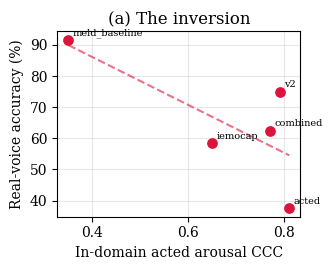

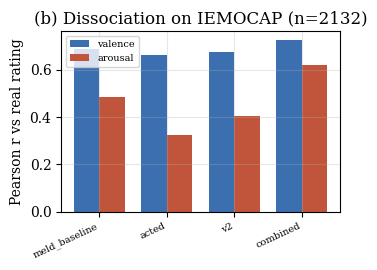

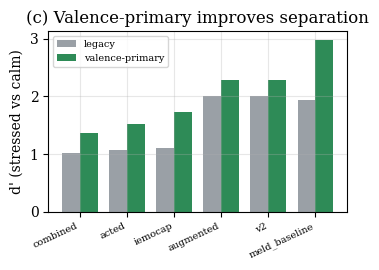

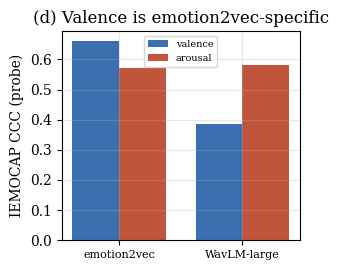

saved 4 figures (PNG+PDF) -> /content/drive/MyDrive/cognivoice/paper_cache/figures


In [24]:
# §6 — IEEE figures (300 DPI) -> Drive
import matplotlib.pyplot as plt, numpy as np
from scipy.stats import pearsonr
plt.rcParams.update({'font.size':10,'font.family':'serif','axes.grid':True,'grid.alpha':0.3})
FIG=CACHE/'figures'; FIG.mkdir(exist_ok=True)
def save(fig,n): fig.tight_layout(); fig.savefig(FIG/f'{n}.png',dpi=300,bbox_inches='tight'); fig.savefig(FIG/f'{n}.pdf',bbox_inches='tight')

# (a) the inversion (conventional scoring)
xs,ys,names=[],[],[]
for ck,g in real_scores.groupby("checkpoint"):
    if ck not in ACTED_CCC: continue
    leg=vlegacy(g.valence.values,g.arousal.values)
    xs.append(ACTED_CCC[ck]); ys.append(((leg>=5.0)==(g.label.values=="stressed")).mean()); names.append(ck.replace('fusion_',''))
xs,ys=np.array(xs),np.array(ys)
fig,ax=plt.subplots(figsize=(3.4,2.8)); ax.scatter(xs,ys*100,c='crimson',s=45,zorder=3)
z=np.polyfit(xs,ys,1); xx=np.linspace(xs.min(),xs.max(),10); ax.plot(xx,np.polyval(z,xx)*100,'--',c='crimson',alpha=.6)
for x,y,n in zip(xs,ys,names): ax.annotate(n,(x,y*100),fontsize=7,xytext=(3,3),textcoords='offset points')
ax.set_xlabel('In-domain acted arousal CCC'); ax.set_ylabel('Real-voice accuracy (%)'); ax.set_title('(a) The inversion'); save(fig,'fig_inversion')

# (b) dissociation on IEMOCAP (cross-corpus)
cross=["fusion_meld_baseline","fusion_acted","fusion_v2","fusion_combined"]; vr,ar=[],[]
for ck in cross:
    pv,pa,_=predict_from_features(MODELS_DIR/f"{ck}.pt",EMB_T,PROS_T); vr.append(pearsonr(pv,VAL_T)[0]); ar.append(pearsonr(pa,ARO_T)[0])
x=np.arange(len(cross)); w=0.38; fig,ax=plt.subplots(figsize=(3.6,2.8))
ax.bar(x-w/2,vr,w,label='valence',color='#3b6fb0'); ax.bar(x+w/2,ar,w,label='arousal',color='#c1553b')
ax.set_xticks(x); ax.set_xticklabels([c.replace('fusion_','') for c in cross],rotation=25,ha='right',fontsize=7)
ax.set_ylabel('Pearson r vs real rating'); ax.set_title('(b) Dissociation on IEMOCAP (n=2132)'); ax.legend(fontsize=7); save(fig,'fig_dissociation')

# (c) d' before/after
dd=dpf.sort_values('d_valprimary'); x=np.arange(len(dd)); w=0.38; fig,ax=plt.subplots(figsize=(3.8,2.8))
ax.bar(x-w/2,dd.d_legacy,w,label='legacy',color='#9aa0a6'); ax.bar(x+w/2,dd.d_valprimary,w,label='valence-primary',color='#2e8b57')
ax.set_xticks(x); ax.set_xticklabels([c.replace('fusion_','') for c in dd.checkpoint],rotation=25,ha='right',fontsize=7)
ax.set_ylabel("d' (stressed vs calm)"); ax.set_title("(c) Valence-primary improves separation"); ax.legend(fontsize=7); save(fig,'fig_dprime')

# (d) encoder comparison (matched size)
encs=[("emotion2vec",E_e2v),("WavLM-large",E_wl)]; vv=[probe(E,Yv) for _,E in encs]; aa=[probe(E,Ya) for _,E in encs]
x=np.arange(len(encs)); w=0.38; fig,ax=plt.subplots(figsize=(3.2,2.8))
ax.bar(x-w/2,vv,w,label='valence',color='#3b6fb0'); ax.bar(x+w/2,aa,w,label='arousal',color='#c1553b')
ax.set_xticks(x); ax.set_xticklabels([n for n,_ in encs],fontsize=8)
ax.set_ylabel('IEMOCAP CCC (probe)'); ax.set_title('(d) Valence is emotion2vec-specific'); ax.legend(fontsize=7); save(fig,'fig_encoder')

plt.show(); print("saved 4 figures (PNG+PDF) ->", FIG)